# Dueling Deep Q-Network (DQN)

Deep Q-Networks (DQN) are **value-based** reinforcement learning algorithms that learn an action-value function \(Q(s,a)\), the expected return of taking action \(a\) in state \(s\) and then following the current policy. Instead of directly learning a policy distribution, DQN picks actions via **argmax over Q-values**, typically with **epsilon-greedy** exploration.

Key ideas:
- **Q-learning with a neural network**:  
  The network approximates \(Q_\theta(s,a)\). The greedy action is:

  `a* = argmax_a Q_θ(s, a)`

- **Temporal-Difference (TD) target**:  
  DQN trains using bootstrapped targets:

  `y = r + γ * (1 - done) * max_{a'} Q_{θ^-}(s', a')`

  where `θ^-` are the **target network** parameters (a delayed copy of the online network).

- **Replay buffer (off-policy learning)**:  
  Experiences `(s, a, r, s', done)` are stored and sampled uniformly (or with priorities) to:
  - break correlations between consecutive samples  
  - reuse data efficiently  
  - stabilize training

- **Target network**:  
  A separate network \(Q_{θ^-}\) is updated periodically (hard update) or slowly (soft update) to make targets less wobbly.

- **Dueling architecture**:  
  Instead of predicting Q-values directly, the model splits into:
  - **Value stream** \(V(s)\) (how good the state is)
  - **Advantage stream** \(A(s,a)\) (how much better an action is vs others)

  Combined as:

  `Q(s,a) = V(s) + (A(s,a) - mean_a A(s,a))`

  This helps in states where the choice of action matters little (or only a few actions matter), improving learning efficiency.

In practice, **Dueling DQN** is a strong and relatively stable baseline for discrete-action games like Connect-4, especially when paired with replay, target networks, and careful exploration scheduling. It’s also a natural fit for transfer learning from supervised “policy-ish” backbones, because the early convolutional features are still doing the same job: “look at board, understand threats, don’t embarrass yourself.”


Version log:
* 0.9 restart
    * using PPO lessons learned as template
* 0.10 final revisti after PPO success


## Links, learning from
[https://github.com/marcpaulo15/RL-connect4/tree/main](https://github.com/marcpaulo15/RL-connect4/tree/main)<br>
[https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html](https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html)
<br>
[https://pettingzoo.farama.org/tutorials/agilerl/DQN/](https://pettingzoo.farama.org/tutorials/agilerl/DQN/)
<br>
[https://www.geeksforgeeks.org/machine-learning/understanding-prioritized-experience-replay/](https://www.geeksforgeeks.org/machine-learning/understanding-prioritized-experience-replay/)
<br>
### Other helpful links

<br>[https://medium.com/@vishwapatel214/building-a-connect-4-game-bot-with-deep-learning-models-dbcd019d8967](https://medium.com/@vishwapatel214/building-a-connect-4-game-bot-with-deep-learning-models-dbcd019d8967)
<br>[https://codebox.net/pages/connect4#:~:text=This%20requires%20a%20lot%20of%20work%20up%2Dfront,possible%20action%20at%20each%20step%20is%20impractical.](https://codebox.net/pages/connect4#:~:text=This%20requires%20a%20lot%20of%20work%20up%2Dfront,possible%20action%20at%20each%20step%20is%20impractical.)
<br>[https://medium.com/advanced-machine-learning/deep-learning-meets-board-games-creating-a-connect-4-ai-using-cnns-and-vits-89c8cdab0041](https://medium.com/advanced-machine-learning/deep-learning-meets-board-games-creating-a-connect-4-ai-using-cnns-and-vits-89c8cdab0041)
<br>[https://medium.com/@piyushkashyap045/understanding-dropout-in-deep-learning-a-guide-to-reducing-overfitting-26cbb68d5575#:~:text=Choosing%20Dropout%20Rate:%20Common%20dropout,is%20better%20for%20simpler%20models.](https://medium.com/@piyushkashyap045/understanding-dropout-in-deep-learning-a-guide-to-reducing-overfitting-26cbb68d5575#:~:text=Choosing%20Dropout%20Rate:%20Common%20dropout,is%20better%20for%20simpler%20models.)
<br>
[https://medium.com/oracledevs/lessons-from-alphazero-connect-four-e4a0ae82af68](https://medium.com/oracledevs/lessons-from-alphazero-connect-four-e4a0ae82af68)
<br>
[https://docs.agilerl.com/en/latest/tutorials/pettingzoo/dqn.html](https://docs.agilerl.com/en/latest/tutorials/pettingzoo/dqn.html)
<br>


## Import dependecies and recheck installation

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from torchinfo import summary
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time
import pprint;
import pandas as pd
import os
import copy
import math
from pathlib import Path
from IPython.display import display, clear_output, HTML

import warnings

print("All dependencies imported successfully.")
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("CUDA not available. Using CPU.")

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

All dependencies imported successfully.
torch version: 2.5.1
CUDA available: True
CUDA version: 11.8
GPU name: NVIDIA GeForce RTX 4090
cuda


### Fixed Random seeds

In [2]:
SEED = 666
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

## Custom imports

In [3]:
from C4.connect4_env import Connect4Env
from C4.fast_connect4_lookahead import Connect4Lookahead
from PPO.ppo_training_phases_config import TRAINING_PHASES, validate_training_phases
from DQN.dueling_qnet192 import DuelingQNet192
from PPO.phase_tracker import PhaseTracker, display_phases_table
from C4.CNet192 import CNet192, save_cnet192, load_cnet192
from C4.connect4_env import Connect4Env
from C4.opening_tracker import OpeningTracker, init_opening_kpis, record_first_move, summarize_opening_kpis
from DQN.dqn_utilities import update_benchmark_winrates, track_result, h2h_append, plot_live_training, plot_is_weights
from C4.connect4_board_display import display_final_boards_DQN
from C4.utilities import *
from PPO.ppo_opponent_sampler import OpponentSampler
from DQN.dqn_loop_helpers_1ch import (
    play_episode_dqn,
    track_result,
    select_opponent_actor,
)
from C4.eval_oppo_dict import *
from DQN.dqn_hall_of_fame import DQNHallOfFame
from DQN.dqn_diagnostics import *
from DQN.dqn_agent import DQNAgent, DQNHyperParams, save_dqn_checkpoint
from DQN.dqn_replay_memory_per import *
from DQN.dqn_phase_manager import PhaseManager
from DQN.dqn_h2h import head_to_head_models
from DQN.dqn_hall_of_fame import DQNHallOfFame
from DQN.dqn_agent_eval import evaluate_and_log_to_excel, plot_eval_bar_summary_from_suite_df

print("Imports succesfull!")

Lookahead = Connect4Lookahead()
env = Connect4Env()

Imports succesfull!


In [4]:
def env_factory():
    return Connect4Env()


## Constants

In [5]:
plot_interval = 10 

In [6]:
LOG_DIR ="Logs/DQN/"
MODEL_DIR ="Models/DQN/"
PLOTS = "Plots/DQN/"
TEMP_DIR ="Models/DQN/TEMP/"           
reset_dir(TEMP_DIR)   

In [7]:
# hard defaults
BENCHMARK_EVERY     = 20
H2H_EVERY           = BENCHMARK_EVERY 
BATCH_SIZE = 256
REWARD_SCALE        = 10 / Connect4Env.WIN_REWARD
SP_REFRESH_EVERY = 50                # episodes
SP_REFRESH_ON_PHASE_CHANGE = True
UPDATES_PER_PLY = 0.5
MIN_REPLAY_SIZE = 10_000
TARGET_SYNC_EVERY_STEPS = 10_000
GLOBAL_SCORE_BASE = 1.4

# Training phases

In [8]:
PHASES = PhaseTracker(TRAINING_PHASES)
L, lastPhase=display_phases_table(TRAINING_PHASES)
print(L, lastPhase)

,start,duration,length,opponent_mix,lr,clip,entropy,epochs,batch_size,steps_per_update,vf_clip,max_grad_norm,target_kl,temperature,center_start,guard_prob,win_now_prob,guard_ply_min,guard_ply_max,distill_coef,mentor_depth,mentor_prob,mentor_coef
phase,,,,,,,,,,,,,,,,,,,,,,,
BASE,0,700,700,"L5:0.11, L3:0.10, L1:0.07, L11:0.07, L13:0.07, L7:0.07, L9:0.07, SP:0.06, L10:0.05, L12:0.05, L2:0.05, L4:0.05, L6:0.05, L8:0.05, POP:0.05, C:0.01, LEFT:0.01, R:0.01",0.0004,0.2,0.0225,8,256,256,0.2,1.0,0.02,1.0,None,None,None,None,None,None,None,None,None
ODD_MORE,700,600,1300,"L3:0.10, L5:0.10, L11:0.08, L13:0.08, L7:0.08, L9:0.08, SP:0.08, L1:0.07, POP:0.06, L10:0.04, L12:0.04, L2:0.04, L4:0.04, L6:0.04, L8:0.04, C:0.01, LEFT:0.01, R:0.01",0.0004,0.2,0.0225,8,256,256,0.2,1.0,0.02,1.0,None,None,None,None,None,None,None,None,None
FINAL,1300,500,1800,"L3:0.10, L5:0.10, SP:0.10, L9:0.09, L11:0.08, L13:0.08, L7:0.08, POP:0.08, L1:0.07, L6:0.05, L10:0.04, L12:0.04, L2:0.03, L4:0.03, L8:0.03",0.0004,0.2,0.0225,8,256,256,0.2,1.0,0.02,1.0,None,None,None,None,None,None,None,None,None
SP_FINALE,1800,200,2000,"SP:0.13, POP:0.12, L9:0.09, L11:0.08, L13:0.08, L1:0.07, L3:0.07, L5:0.07, L7:0.07, L6:0.05, L10:0.04, L12:0.04, L2:0.03, L4:0.03, L8:0.03",0.0004,0.2,0.0225,8,256,256,0.2,1.0,0.02,1.0,None,None,None,None,None,None,None,None,None


2000 SP_FINALE


# Training session name - settings


In [9]:
number_episodes = L # all
NUM_EPISODES  = number_episodes
begin_start_time = time.time()
model_path = "PPO_Models/PPO_2004.pt"
#model_path = "SupervisedModels/BASE_10.pt" #
model_name = model_path.split("/")[-1].split(".")[0]
run_name =  "DQN"[:10]
time_str = time.strftime('%Y-%m-%d %H-%M-%S', time.localtime(begin_start_time))
tag = f"{run_name}-{lastPhase}-{model_name}"
TRAINING_SESSION = f"PPO-{number_episodes}-{tag} - at-{time_str}"
print("Start training session", TRAINING_SESSION)

Start training session PPO-2000-DQN-SP_FINALE-PPO_2004 - at-2026-05-06 09-41-14


## Hall of Fame / policy ensemble

In [10]:
HOF_METASCORES = {
    "PPO_Models/PPO_2004.pt": 0.866,
    "PPO_Models/PPO_2002.pt": 0.623,
    "PPO_Models/PPO_2003.pt": 0.503,
}

In [11]:
hof = DQNHallOfFame(device=DEVICE)

for path, score in HOF_METASCORES.items():
    name = Path(path).stem
    hof.add_member(name=name, ckpt_path=path, metascore=score)

print("HOF members:", hof.list_members())

ENSEMBLE_NAMES = hof.list_members()
ensemble_policy = hof.build_ensemble(ENSEMBLE_NAMES, use_metascore_weights=True)

for p in ensemble_policy.parameters():
    p.requires_grad_(False)
ensemble_policy.eval()

print(f"Using {len(ENSEMBLE_NAMES)} checkpoints in ensemble.")

HOF members: ['PPO_2004', 'PPO_2002', 'PPO_2003']
Using 3 checkpoints in ensemble.


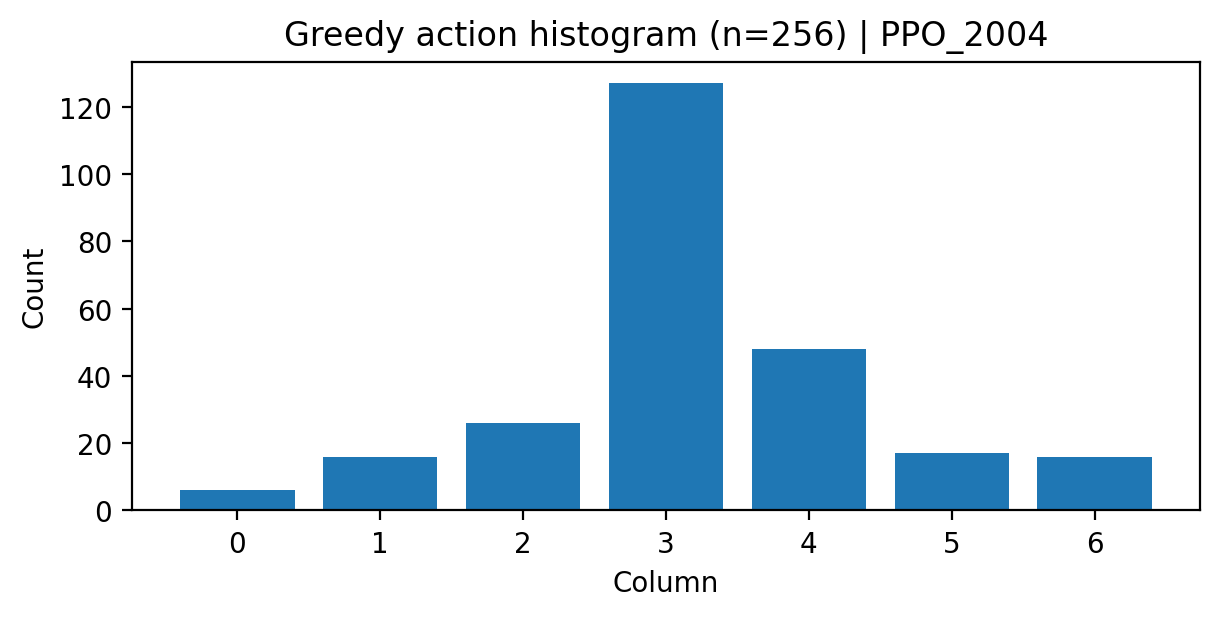

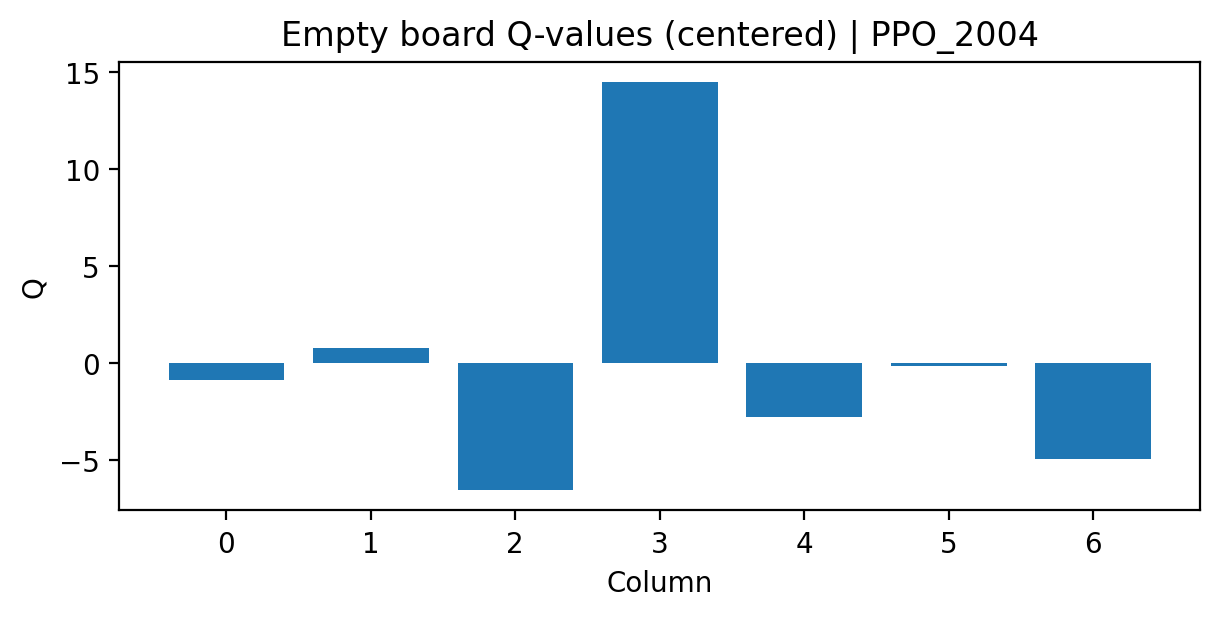

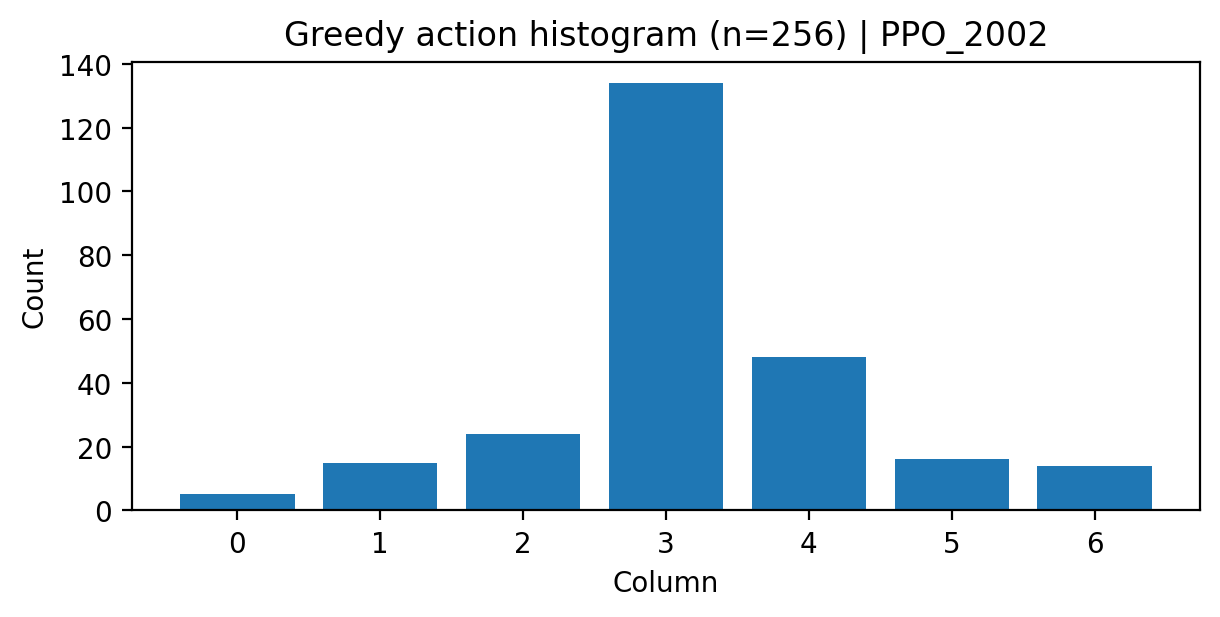

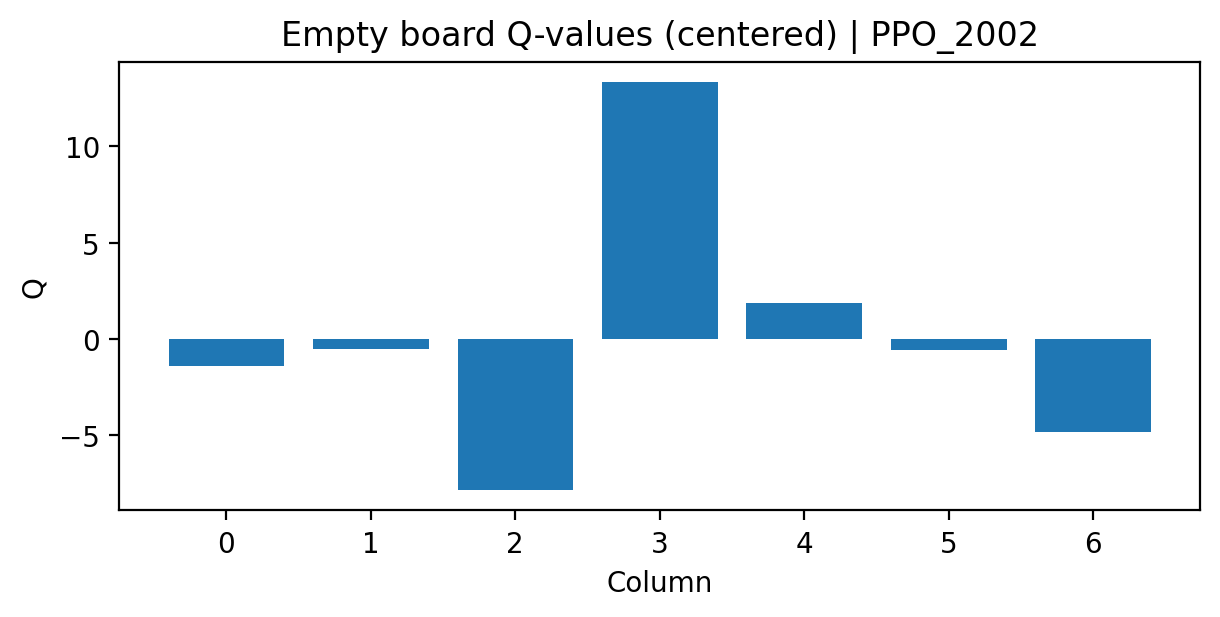

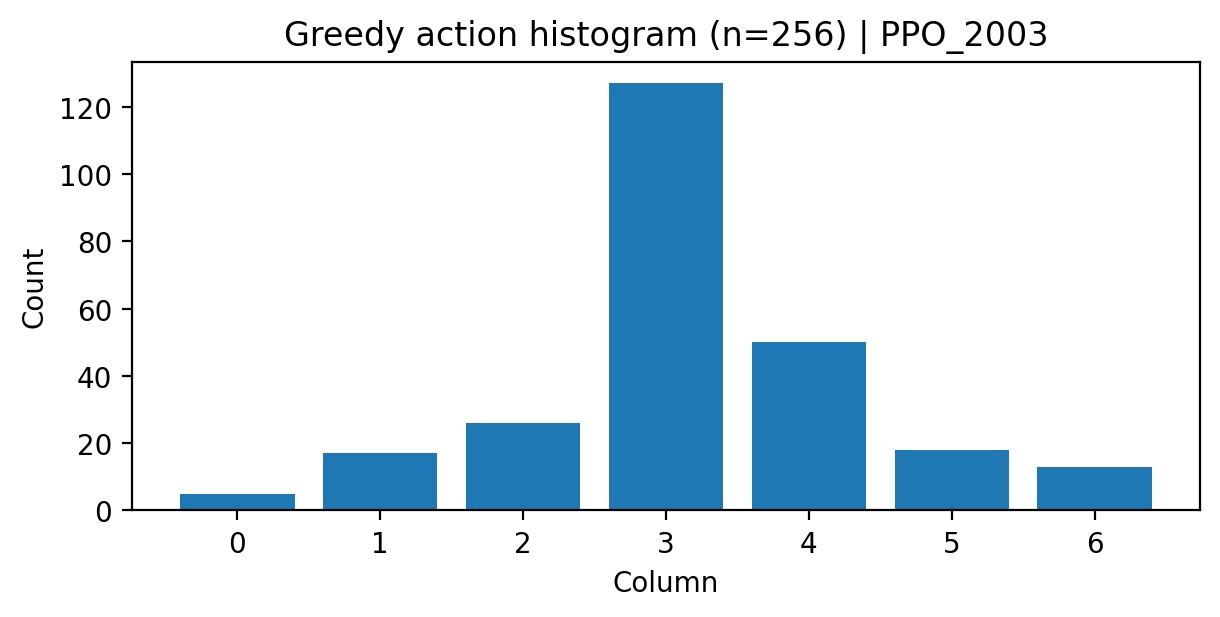

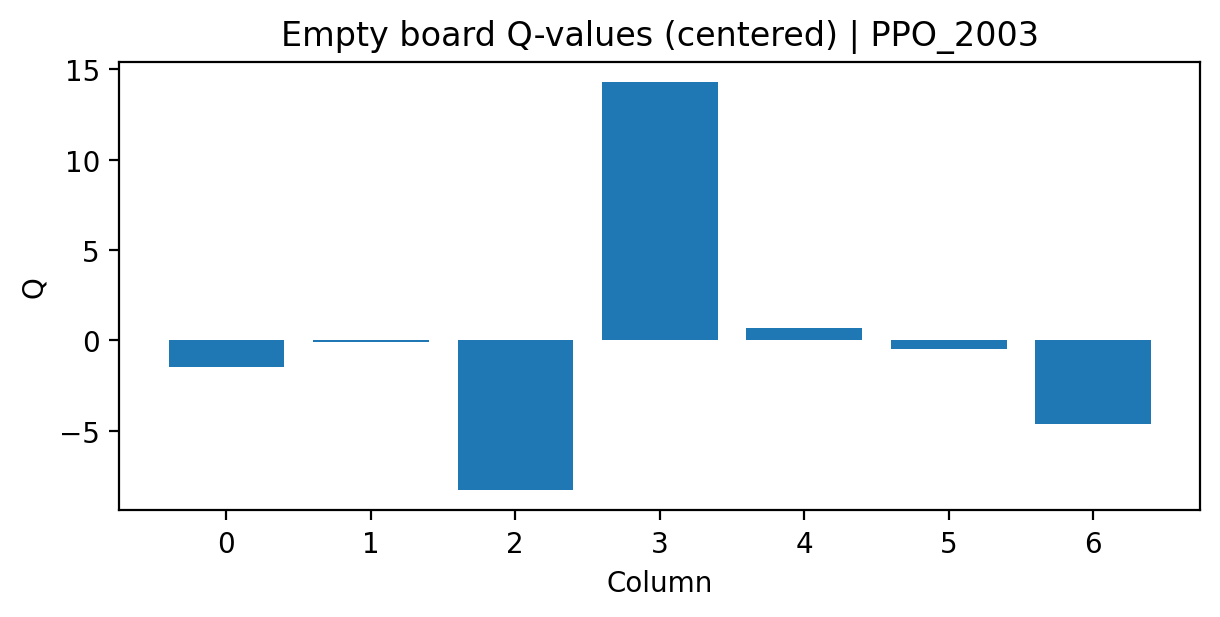

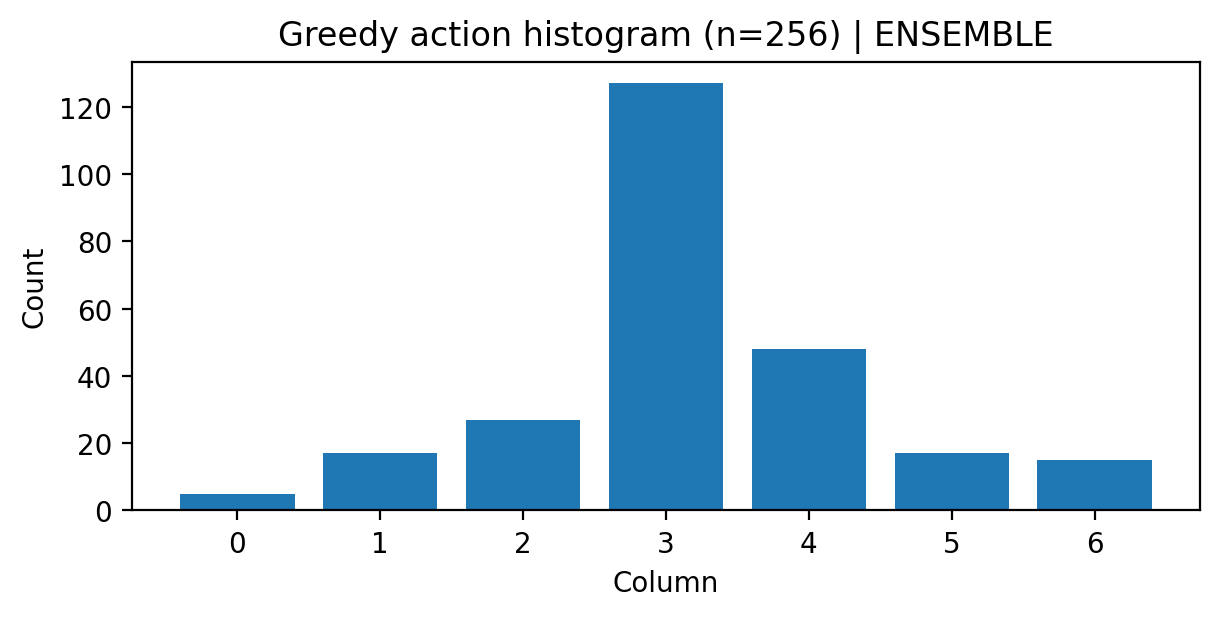

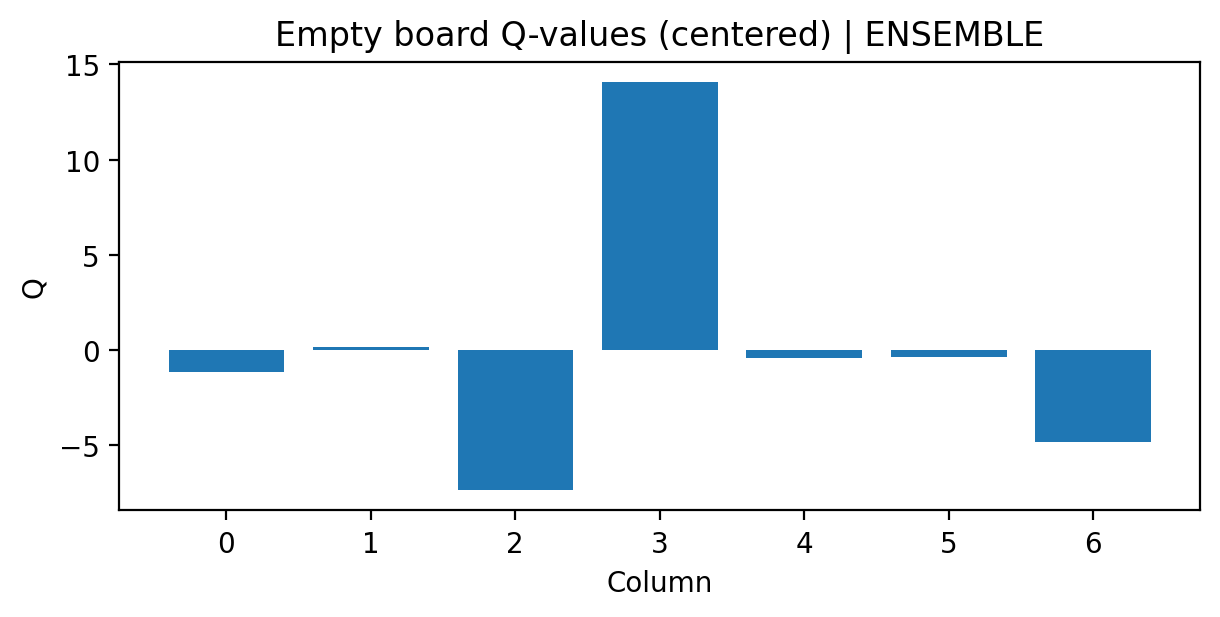

In [12]:
for name in hof.list_members():
    pol = hof.ensure_loaded(name)
    counts = greedy_action_histogram(pol, env, device=DEVICE, n_states=256, max_ply=18, seed=666)
    q0 = empty_board_q_values(pol, env, device=DEVICE)

    fig1 = plot_greedy_action_histogram(counts, model_name=name)
    fig2 = plot_empty_board_q(q0, model_name=name)
    display(fig1); display(fig2)
    plt.close(fig1); plt.close(fig2)

# and the ensemble itself:
counts = greedy_action_histogram(ensemble_policy, env, device=DEVICE, n_states=256, max_ply=18, seed=666)
q0 = empty_board_q_values(ensemble_policy, env, device=DEVICE)
display(plot_greedy_action_histogram(counts, model_name="ENSEMBLE"))
display(plot_empty_board_q(q0, model_name="ENSEMBLE"))

# DQN

In [13]:
hp = DQNHyperParams(
    lr=2e-4,
    gamma=0.99,
    epsilon=0.10,
    epsilon_min=0.02,
    epsilon_decay=0.999,
    batch_size=256,

    # Until your N-step bank is populated + sign-correct, keep it 1-step:
    per_mix_1step=1.0,

    target_update_mode="soft",
    tau=0.005,
)

agent, ckpt = DQNAgent.from_cnet192_checkpoint(
    model_path=model_path,
    device=DEVICE,
    strict=True,
    freeze_conv=True,          # good warm-start default
    memory_capacity=500_000,
    hparams=hp,
    seed=0,
)

print("Loaded:", model_path)
print("Checkpoint cfg:", (ckpt.get("cfg", {}) if isinstance(ckpt, dict) else {}))
print("Conv frozen:", not next(agent.q_net.conv1.parameters()).requires_grad)

total = sum(p.numel() for p in agent.q_net.parameters())
trainable = sum(p.numel() for p in agent.q_net.parameters() if p.requires_grad)
print(f"Params trainable/total: {trainable}/{total}")

Loaded: PPO_Models/PPO_2004.pt
Checkpoint cfg: {'arch': 'cnet192', 'use_mid_3x3': True, 'input_channels': 1}
Conv frozen: True
Params trainable/total: 297032/779912


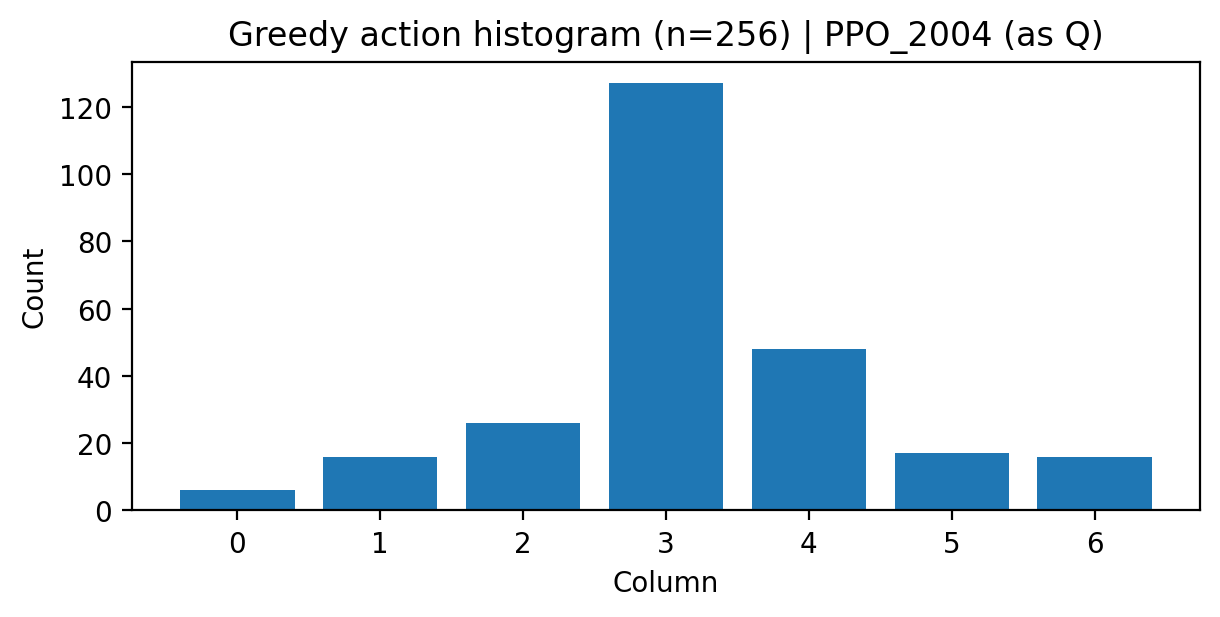

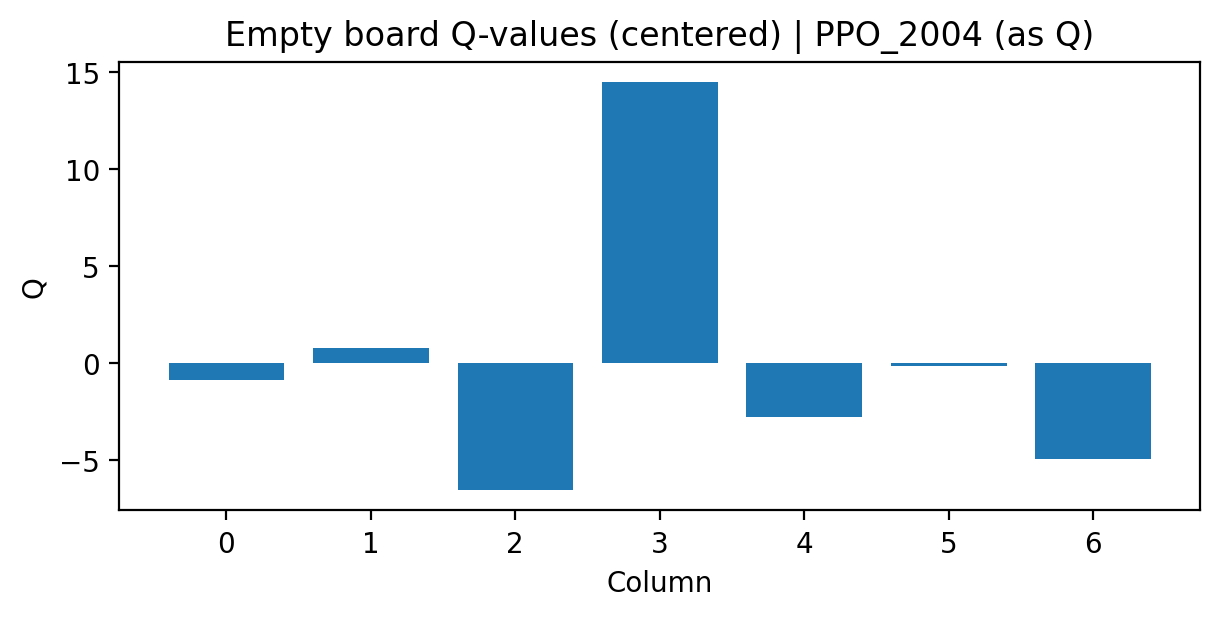

In [14]:
counts, q0, fig_hist, fig_q0, _ = run_quick_diagnostics(
    agent.q_net,
    env,
    device=DEVICE,
    model_name=f"{model_name} (as Q)",
    n_states=256,
    max_ply=18,
    seed=666,
)

display(fig_hist)
display(fig_q0)

In [15]:
# ==== H2H inline metric config ====
H2H_ENABLED      = True
H2H_GAMES        = 200           # e.g., 150–250 ~ quick
H2H_SEED         = SEED

H2H_BASELINE_PATH = f"{TEMP_DIR}H2H_baseline.pt"
H2H_KEEP_TEMPS    = 200          # keep last N temp ckpts
h2h_history       = {"episode": [], "score": [], "lo": [], "hi": [], "n": []}
ensemble_h2h_history       = {"episode": [], "score": [], "lo": [], "hi": [], "n": []}
_h2h_temp_paths   = []
h2h_best_score    = -1.0

baseline_model = agent.q_net
assert isinstance(baseline_model, torch.nn.Module), f"baseline_model must be nn.Module, got {type(baseline_model)}"

baseline_model.eval()
save_cnet192(
    model=baseline_model,
    path=H2H_BASELINE_PATH,
    meta={
        "tag": "H2H_baseline",
        "episode": 0,
        "seed": int(H2H_SEED),
        "source_model_path": str(model_path),
    },
)

print(f"✅ H2H baseline saved to: {H2H_BASELINE_PATH}")

✅ H2H baseline saved to: Models/DQN/TEMP/H2H_baseline.pt


In [16]:
def refresh_sp_snapshot():
    """Refresh frozen self-play opponent from current student weights."""
    sp_q_net.load_state_dict(agent.q_net.state_dict(), strict=True)
    sp_q_net.eval()


# ---- self-play snapshot (frozen opponent) ----
sp_q_net = copy.deepcopy(agent.q_net).to(DEVICE)
sp_q_net.eval()
for p in sp_q_net.parameters():
    p.requires_grad_(False)

# ---- training mode: freeze conv or not ----
FREEZE_CONV = False  # True = heads-only warm-start, False = train full net
agent.freeze_conv_block(FREEZE_CONV)

agent.q_net.train(True)
agent.target_net.eval()

total = sum(p.numel() for p in agent.q_net.parameters())
trainable = sum(p.numel() for p in agent.q_net.parameters() if p.requires_grad)
print(f"Trainable/total params: {trainable}/{total} | conv frozen: {FREEZE_CONV}")

# ---- opening stats ----
openings = OpeningTracker(cols=7, log_every=plot_interval, ma_window=12)
opening_kpis = openings.kpis


Trainable/total params: 779912/779912 | conv frozen: False


In [17]:
# ---------------- Histories (single source of truth) ----------------

def _append_h2h_row(H: dict, episode: int, res: dict) -> None:
    H["episode"].append(int(episode))
    for k in ("A_score_rate", "A_win_rate", "A_loss_rate", "draw_rate", "n_games"):
        H[k].append(float(res.get(k, float("nan"))))


def _append_h2h_ci(hist: dict, episode: int, res: dict) -> None:
    """
    Convert head_to_head_models() output into plot-ready history:
      score = A_score_rate
      CI ~ normal approx on outcome in {1, 0.5, 0}
    """
    n = int(res.get("n_games", 0) or 0)
    n_eff = max(1, n)

    score = float(res.get("A_score_rate", 0.0))

    p_win  = float(res.get("A_win_rate", 0.0))
    p_loss = float(res.get("A_loss_rate", 0.0))
    p_draw = float(res.get("draw_rate", max(0.0, 1.0 - p_win - p_loss)))

    # Outcome Z ∈ {1, 0.5, 0}
    # E[Z] = score
    # E[Z^2] = 1*p_win + 0.25*p_draw
    ez2 = 1.0 * p_win + 0.25 * p_draw
    var = max(0.0, ez2 - score * score)

    se = math.sqrt(var / n_eff)
    half = 1.96 * se

    lo = max(0.0, score - half)
    hi = min(1.0, score + half)

    hist["episode"].append(int(episode))
    hist["score"].append(float(score))
    hist["lo"].append(float(lo))
    hist["hi"].append(float(hi))



# Core episode histories (these are what plot_live_training expects)
reward_history = []              # float per episode
win_history = []                 # 1.0 win, -1.0 loss, 0.5 draw (or whatever track_result appends)
phase_history = []               # str phase name per episode
opp_timeline = []                # str opponent key per episode

epsilon_history = []             # float per episode
epsilon_min_history = []         # float per episode

# Optional (but referenced by plot_live_training signature)
memory_prune_low_history = []    # float per episode, use 0.0 if not pruning
center_prob_history = []         # float per episode, use nan or 0.0 if not tracking
tu_interval_history = []         # int per episode
tau_history = []                # float per episode
tu_mode_history = []            # str per episode

# Replay diagnostics per episode (your own, used for extra plots or debugging)
loss_history = []               # mean loss over updates this episode (nan if none)
td_mean_history = []            # mean |TD| over updates (nan if none)
q_mean_history = []             # mean |Q| over updates (nan if none)
w_mean_history = []             # mean IS-weight over updates (nan if none)

# Structured metrics table (1 row per episode)
dqn_metrics_history = {
    "episodes": [],
    "phase": [],
    "opp": [],
    "epsilon": [],
    "epsilon_min": [],
    "reward": [],
    "result": [],               # optional: store final_result string
    "loss": [],
    "td_abs_mean": [],
    "q_abs_mean": [],
    "w_mean": [],
    "per_beta": [],
    "memory_size": [],
    "tu_mode": [],
    "tu_interval": [],
    "tau": [],
}

h2h_history = {
    "episode": [],
    "score": [],
    "lo": [],
    "hi": [],
}

pop_h2h_history = {
    "episode": [],
    "score": [],
    "lo": [],
    "hi": [],
}


benchmark_history = None        # will become a dict from update_benchmark_winrates

# Running totals
win_count = 0
loss_count = 0
draw_count = 0


### Live plot

In [18]:
plots_handle = display(HTML("<b>Live training plot will appear here.</b>"), display_id=True)
fig_ep = None 

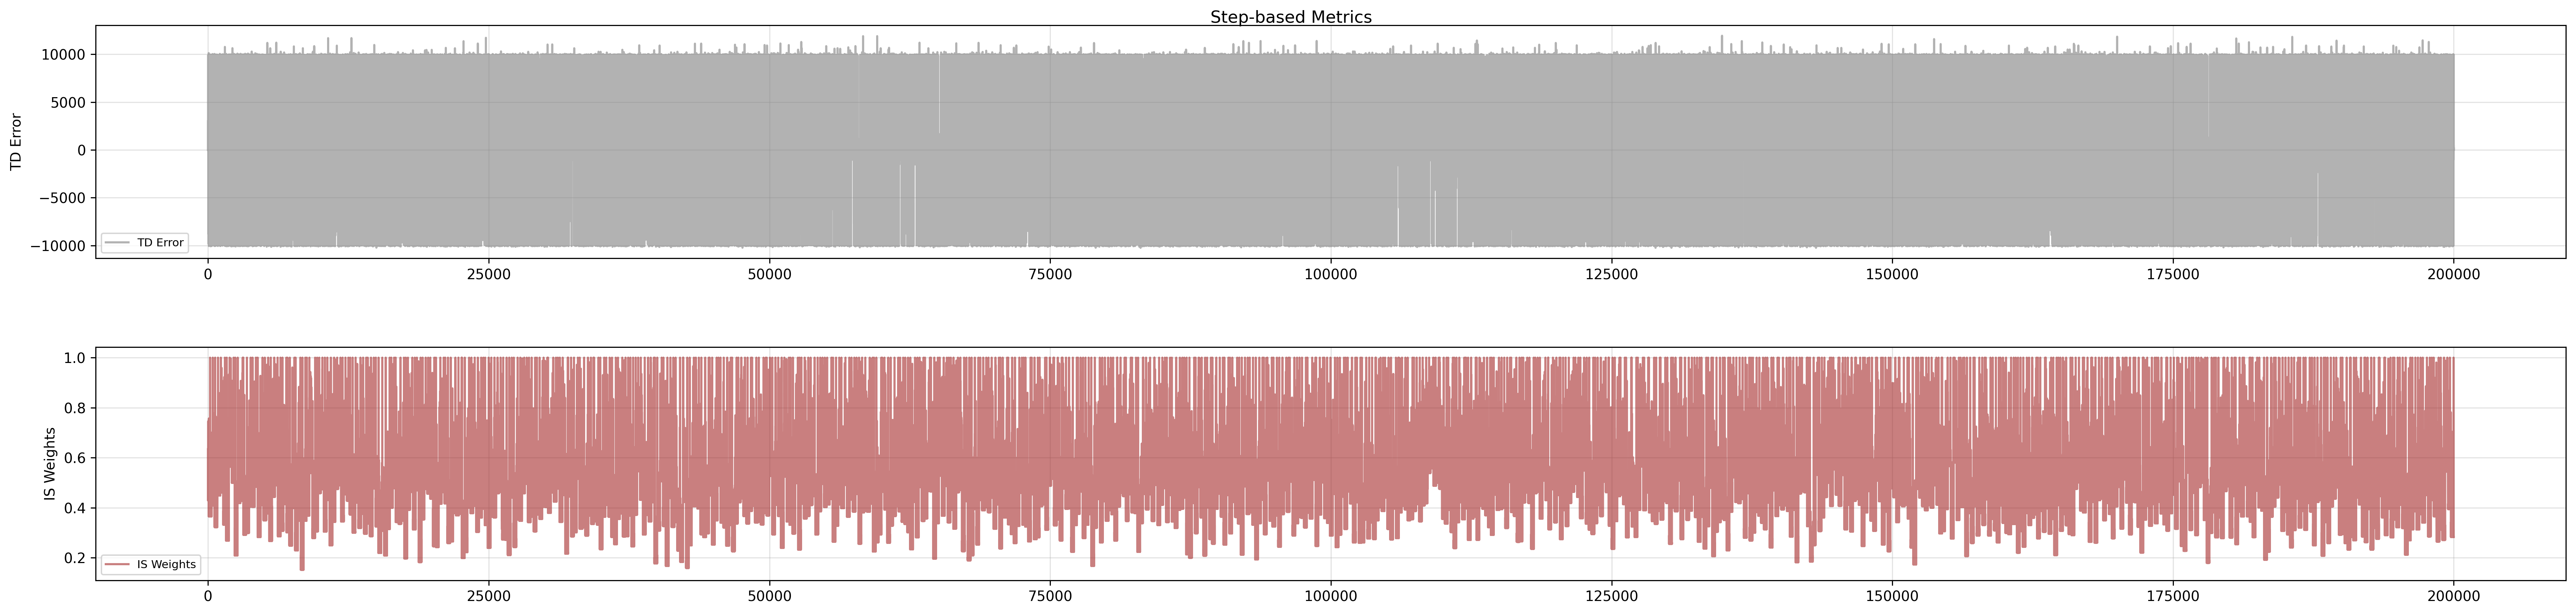

In [19]:
steps_handle = display(None, display_id=True)
fig_step = None

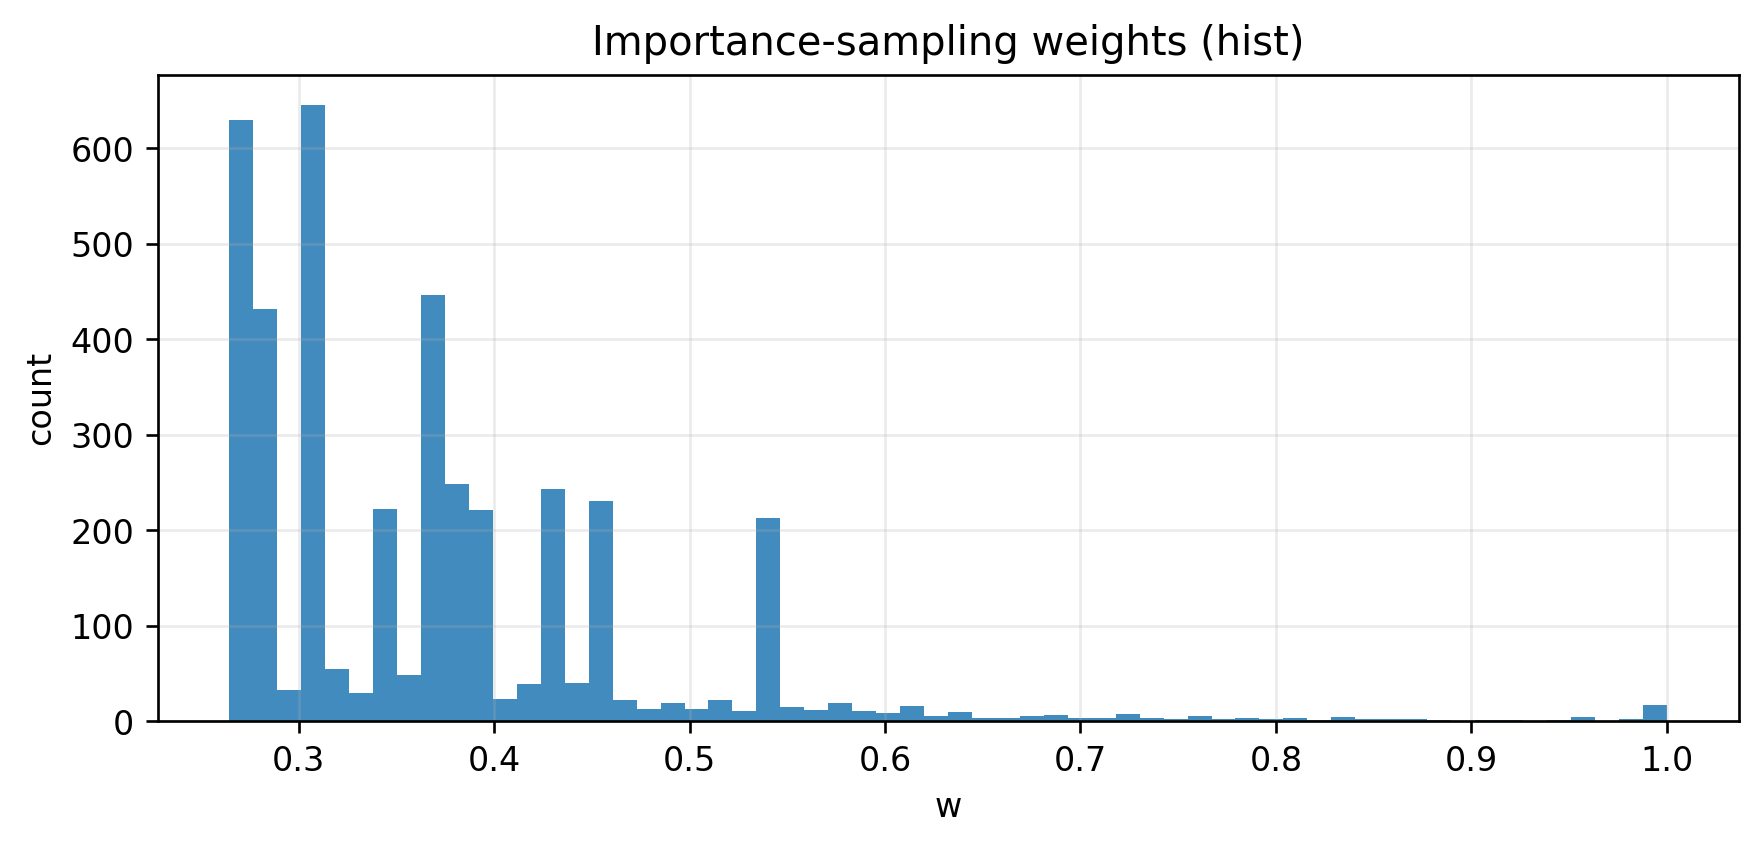

In [20]:
histograms_handle = display(None, display_id=True)
fig_w = None

## Training Loop

In [ ]:
################## LOOP ##################
rng = np.random.default_rng(int(SEED))

steps_total = 0
current_phase_name = None
opponent_sampler = None

# SP snapshot
sp_q_net = copy.deepcopy(agent.q_net).to(DEVICE)
sp_q_net.eval()
for p in sp_q_net.parameters():
    p.requires_grad_(False)

# keep last known scores for logging/bench rows
last_h2h_score = 0.0
last_pop_score = 0.0

start_time = time.time()

with tqdm(total=NUM_EPISODES, desc="DQN Episodes", dynamic_ncols=True) as pbar:
    for ep in range(1, NUM_EPISODES + 1):

        # defaults for downstream benchmark logging
        score = last_h2h_score
        ensemble_score = last_pop_score

        # ---------------- phase ----------------
        phase_info, changed = PHASES.start_episode(ep)
        phase_name = phase_info.name
        phase_cfg = TRAINING_PHASES[phase_name]
        dqn_p = phase_cfg.get("dqn_params", {})  # <- your attached_dqn_defaults()

        if changed:
            current_phase_name = phase_name

            # core DQN knobs
            if "lr" in dqn_p: agent.set_lr(dqn_p["lr"])
            if "gamma" in dqn_p: agent.hp.gamma = float(dqn_p["gamma"])
            if "epsilon" in dqn_p: agent.set_epsilon(dqn_p["epsilon"])
            if "epsilon_min" in dqn_p: agent.set_epsilon_min(dqn_p["epsilon_min"])
            if "epsilon_decay" in dqn_p: agent.set_epsilon_decay(dqn_p["epsilon_decay"])
            if "per_mix_1step" in dqn_p: agent.set_per_mix_1step(dqn_p["per_mix_1step"])
            if "per_beta" in dqn_p: agent.per_beta = float(dqn_p["per_beta"])

            # target update
            tu_mode = dqn_p.get("TU_mode", agent.hp.target_update_mode)
            tau     = dqn_p.get("tau", agent.hp.tau)
            tu_int  = dqn_p.get("TU", agent.hp.target_update_interval)
            agent.configure_target_update(mode=tu_mode, tau=tau, interval=tu_int, reset_timer=True)

            # optional conv freeze (warm-start)
            if "freeze_conv" in dqn_p:
                agent.freeze_conv_block(bool(dqn_p["freeze_conv"]), rebuild_optimizer=True)

            # rebuild opponent sampler for this phase
            mix = phase_cfg.get("opponent_mix", None) or {"R": 1.0}
            opponent_sampler = OpponentSampler({str(k): float(v) for k, v in mix.items()}, seed=ep)

            # opening tracker phase marker
            if openings is not None:
                openings.mark_phase(ep, phase_name)

        # ---------------- refresh SP snapshot ----------------
        if (ep % SP_REFRESH_EVERY) == 0 or changed:
            sp_q_net.load_state_dict(agent.q_net.state_dict(), strict=True)
            sp_q_net.eval()

        # ---------------- choose opponent ----------------
        sampled_key = opponent_sampler.sample_key() if opponent_sampler else "R"
        opp_timeline.append(sampled_key)

        opp_act, opp_tag = select_opponent_actor(
            sampled_key=sampled_key,
            device=DEVICE,
            rng=rng,
            sp_q_net=sp_q_net,
            pop_ensemble=ensemble_policy,
            lookahead=Lookahead,
        )

        # ---------------- play episode ----------------
        env = Connect4Env()
        ep_reward, final_result, plies = play_episode_dqn(
            env=env,
            agent=agent,
            opponent_act=opp_act,
            opponent_tag=opp_tag,
            store_opponent_moves=True,
            epsilon_override=None,
            alt_start=True,
            episode_idx0=ep - 1,
            rng=rng,
            openings=openings,
        )

        steps_total += int(plies)

        if openings is not None:
            openings.maybe_log(ep)

        # ---------------- updates ----------------
        ep_losses = []
        ep_td = []
        ep_q = []
        ep_w = []

        n_updates = int(max(1, round(plies * UPDATES_PER_PLY)))
        if len(agent.memory) >= max(BATCH_SIZE, MIN_REPLAY_SIZE):
            for _ in range(n_updates):
                _ = agent.replay(batch_size=BATCH_SIZE)
                st = agent.last_replay_stats
                if st is not None:
                    ep_losses.append(float(st.get("loss", 0.0)))
                    ep_td.append(float(st.get("td_abs_mean", 0.0)))
                    ep_q.append(float(st.get("q_abs_mean", 0.0)))
                    ep_w.append(float(st.get("w_mean", 0.0)))


        agent.decay_epsilon()

       # ---------------- bookkeeping / histories ----------------

        reward_history.append(float(ep_reward))
        phase_history.append(str(phase_name))
        
        # result tracking
        w, l, d = track_result(final_result, win_history)
        win_count += w
        loss_count += l
        draw_count += d
        
        # epsilon series
        epsilon_history.append(float(agent.epsilon))
        epsilon_min_history.append(float(agent.hp.epsilon_min))
        
        # "optional but required by plot_live_training signature" series
        memory_prune_low_history.append(0.0)                   # not pruning in this loop
        center_prob_history.append(float("nan"))               # not tracking, keep nan so plots can ignore
        
        tu_mode_history.append(str(agent.hp.target_update_mode))
        tu_interval_history.append(int(agent.hp.target_update_interval))
        tau_history.append(float(agent.hp.tau))
        
        # replay-episode aggregates (nan if no updates)
        loss_ep = float(np.mean(ep_losses)) if ep_losses else float("nan")
        td_ep   = float(np.mean(ep_td))     if ep_td     else float("nan")
        q_ep    = float(np.mean(ep_q))      if ep_q      else float("nan")
        w_ep    = float(np.mean(ep_w))      if ep_w      else float("nan")
        
        loss_history.append(loss_ep)
        td_mean_history.append(td_ep)
        q_mean_history.append(q_ep)
        w_mean_history.append(w_ep)
        
        # metrics table row
        dqn_metrics_history["episodes"].append(int(ep))
        dqn_metrics_history["phase"].append(str(phase_name))
        dqn_metrics_history["opp"].append(str(sampled_key))
        dqn_metrics_history["epsilon"].append(float(agent.epsilon))
        dqn_metrics_history["epsilon_min"].append(float(agent.hp.epsilon_min))
        dqn_metrics_history["reward"].append(float(ep_reward))
        dqn_metrics_history["result"].append(final_result)
        
        dqn_metrics_history["loss"].append(loss_ep)
        dqn_metrics_history["td_abs_mean"].append(td_ep)
        dqn_metrics_history["q_abs_mean"].append(q_ep)
        dqn_metrics_history["w_mean"].append(w_ep)
        
        dqn_metrics_history["per_beta"].append(float(agent.per_beta))
        dqn_metrics_history["memory_size"].append(int(len(agent.memory)))
        
        dqn_metrics_history["tu_mode"].append(str(agent.hp.target_update_mode))
        dqn_metrics_history["tu_interval"].append(int(agent.hp.target_update_interval))
        dqn_metrics_history["tau"].append(float(agent.hp.tau))


        # progress
        avg_r = float(np.mean(reward_history[-25:])) if reward_history else 0.0
        pbar.set_postfix(
            phase=phase_name,
            opp=sampled_key,
            r25=f"{avg_r:.2f}",
            eps=f"{agent.epsilon:.3f}",
            W=win_count,
            L=loss_count,
            D=draw_count,
            mem=len(agent.memory),
        )

        # ---------------- H2H ----------------
        if H2H_ENABLED and (ep == 1 or (ep % H2H_EVERY) == 0):
            rng_h2h = np.random.default_rng(int(SEED + ep))
            k_h2h = sample_opening_noise_k(OPENING_NOISE_K, rng_h2h)

            # ---- optional tmp snapshot (trimmed) ----
            tmp_path = f"{TEMP_DIR}{TRAINING_SESSION}_H2H_tmp_ep{ep}.pt"
            save_dqn_checkpoint(
                agent,
                tmp_path,
                tag="H2H_tmp",
                session=TRAINING_SESSION,
                phase=str(phase_name),
                episode=int(ep),
                seed=int(SEED + ep),
                t=float(time.time()),
            )
            _h2h_temp_paths.append(tmp_path)
            
            # trim old temps
            while len(_h2h_temp_paths) > H2H_KEEP_TEMPS:
                old = _h2h_temp_paths.pop(0)
                try:
                    os.remove(old)
                except Exception:
                    pass  
    
            if baseline_model is not None:
                res = head_to_head_models(
                    agent.q_net,                 # modelA
                    baseline_model,              # modelB
                    env_factory=env_factory,
                    n_games=H2H_GAMES,
                    device=DEVICE,
                    opening_noise_k=k_h2h,
                    seed=int(SEED + ep),
                    paired_openings=True,
                )
                score = float(res.get("A_score_rate", 0.0))
                last_h2h_score = score
                _append_h2h_ci(h2h_history, ep, res)

            if ensemble_policy is not None:
                rng_pop = np.random.default_rng(int(SEED + ep + 999))
                k_pop = sample_opening_noise_k(OPENING_NOISE_K, rng_pop)
        
                res_pop = head_to_head_models(
                    agent.q_net,
                    ensemble_policy,
                    env_factory=env_factory,
                    n_games=H2H_GAMES,
                    device=DEVICE,
                    opening_noise_k=k_pop,
                    seed=int(SEED + ep + 999),
                    paired_openings=True,
                )
                ensemble_score = float(res_pop.get("A_score_rate", 0.0))
                last_pop_score = ensemble_score
                _append_h2h_ci(pop_h2h_history, ep, res_pop)

            # ---- best H2H score checkpoint  ----
            if ep >= 100 and score >= h2h_best_score:
                h2h_best_score = float(score)
                best_path = f"{TEMP_DIR}H2H_best_score({h2h_best_score:.3f})_ep{ep}.pt"
                save_dqn_checkpoint(
                    agent,
                    best_path,
                    tag="H2H_best",
                    session=TRAINING_SESSION,
                    phase=str(phase_name),
                    episode=int(ep),
                    seed=int(SEED + ep),
                    score=float(score),
                    t=float(time.time()),
                ) 

        # ---------------- Benchmark (Excel-capable) ----------------
        if ep == 1 or (ep % BENCHMARK_EVERY) == 0:
            
            benchmark_history = update_benchmark_winrates(
                agent=agent,
                env=env_factory(),
                device=DEVICE,
                Lookahead=Connect4Lookahead,  # keep what your eval expects
                episode=ep,
                history=benchmark_history,
                save=f"{LOG_DIR}{TRAINING_SESSION}-benchmark.xlsx",
                opponents_cfg=EVAL_CFG,
                score=float(score),
                ensemble_score=float(ensemble_score),
                center_rate=openings.get_last_logged_center_rate() if openings is not None else 0.0,
                global_base=GLOBAL_SCORE_BASE,
            )


        # ---------------- Live plot ----------------
        if (ep % plot_interval) == 0:
            avg_reward = float(np.mean(reward_history[-25:])) if reward_history else 0.0
        
            fig_ep, fig_step = plot_live_training(
                ep,
                reward_history,
                win_history,
                epsilon_history,
                str(current_phase_name),
                win_count,
                loss_count,
                draw_count,
                TRAINING_SESSION,
                epsilon_min_history,
                memory_prune_low_history,
                agent=agent,
                bench_history=benchmark_history,
                bench_smooth_k=3,
                tu_interval_history=tu_interval_history,
                tau_history=tau_history,
                tu_mode_history=tu_mode_history,
                guard_prob_history=None,                 # youre not tracking this
                center_prob_history=center_prob_history, # exists, contains nan
                openings=openings,
                h2h_history=h2h_history,
                pop_h2h_history=pop_h2h_history, 
                opponent_timeline = opp_timeline,
                return_figs=True,
                save=False,
            )
        
            if fig_ep is not None:
                plots_handle.update(fig_ep)
                plt.close(fig_ep)
        
            if fig_step is not None:
                steps_handle.update(fig_step)
                plt.close(fig_step)

           
            fig_w = plot_is_weights(agent, return_figs=True)
            if fig_w is not None:
                histograms_handle.update(fig_w)
                plt.close(fig_w)


        pbar.update(1)

elapsed = (time.time() - start_time) / 60.0
print(f"Training finished in {elapsed:.1f} min")


DQN Episodes:   0%|          | 0/2000 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-11:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Lookahead-13:   0%|          | 0/2 [00:00<?, ?it/s]

Opponent: Random:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Center:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Opponent: Lookahead-2:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-3:   0%|          | 0/30 [00:00<?, ?it/s]

Opponent: Lookahead-4:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-5:   0%|          | 0/10 [00:00<?, ?it/s]

Opponent: Lookahead-6:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-7:   0%|          | 0/4 [00:00<?, ?it/s]

Opponent: Lookahead-9:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
summarize_opening_kpis(opening_kpis)

In [ ]:
window = 300
smoothed = [np.mean(reward_history[max(0, i-window):i+1]) for i in range(len(reward_history))]

final_reward_fig, final_reward_ax = plt.subplots(figsize=(10, 5))
final_reward_ax.plot(smoothed, label=f"Smoothed Reward (window={window})")

# --- Add phase transitions ---
y_text = np.nanmax(smoothed) if len(smoothed) else 0.0
for name, meta in TRAINING_PHASES.items():
    ep = meta.get("length", None)
    if ep is not None and ep <= len(reward_history):
        final_reward_ax.axvline(x=ep, color='black', linestyle='dotted', linewidth=1)
        final_reward_ax.text(ep + 5, y_text * 0.95, name, rotation=90, va='top', ha='left', fontsize=8)

final_reward_ax.set_title("Smoothed Reward Over Episodes")
final_reward_ax.set_xlabel("Episode")
final_reward_ax.set_ylabel("Smoothed Reward")
final_reward_ax.legend()
final_reward_ax.grid(True)
final_reward_fig.tight_layout()
plt.show()


In [ ]:
fig_ep, fig_step = plot_live_training(
                ep,
                reward_history,
                win_history,
                epsilon_history,
                str(current_phase_name),
                win_count,
                loss_count,
                draw_count,
                TRAINING_SESSION,
                epsilon_min_history,
                memory_prune_low_history,
                agent=agent,
                bench_history=benchmark_history,
                bench_smooth_k=3,
                tu_interval_history=tu_interval_history,
                tau_history=tau_history,
                tu_mode_history=tu_mode_history,
                guard_prob_history=None,                 # youre not tracking this
                center_prob_history=center_prob_history, # exists, contains nan
                openings=openings,
                h2h_history=h2h_history,
                pop_h2h_history=pop_h2h_history, 
                opponent_timeline = opp_timeline,
                return_figs=True,
                save=True, path = PLOTS
            )
plt.close(fig_ep)

## Save model

In [ ]:
timestamp = time.strftime("%Y%m%d-%H%M%S")
model_path = f"{MODEL_DIR}{TRAINING_SESSION}_Connect4 DQN_model_{timestamp} episodes-{number_episodes}.pt"

save_dqn_checkpoint(
                    agent,
                    model_path,
                    tag="Final",
                    session=TRAINING_SESSION,
                    phase=str(phase_name),
                    episode=int(ep),
                    seed=int(SEED + ep),
                    score=float(score),
                    t=float(time.time()),
                ) 

print(f"Model saved to {model_path}")


# Evaluation

In [ ]:
check_score   = float(benchmark_history["check_score"][-1])   if benchmark_history and benchmark_history.get("check_score") else None
ensemble_score= float(benchmark_history["ensemble_score"][-1])if benchmark_history and benchmark_history.get("ensemble_score") else None
center_rate   = float(benchmark_history["center_rate"][-1])   if benchmark_history and benchmark_history.get("center_rate") else None

suite_df, row_df = evaluate_and_log_to_excel(
    agent=agent,
    opponents_cfg=EVALUATION_OPPONENTS,
    excel_path="EVAL_DQN_results.xlsx",
    run_tag=TRAINING_SESSION,
    device=DEVICE,
    lookahead=Lookahead,          # your Connect4Lookahead instance
    seed=SEED,
    episodes=ep,                  # last episode
    progress=True,
    check_score=check_score,
    ensemble_score=ensemble_score,
    center_rate=center_rate,
)

display(suite_df)
display(row_df)

fig = plot_eval_bar_summary_from_suite_df(
    suite_df,
    model_name=TRAINING_SESSION,
    save_path=f"{PLOTS}DQN-{TRAINING_SESSION}-evaluation_plot.png",
)

import matplotlib.pyplot as plt
plt.show(fig)

In [ ]:
display(suite_df)

In [ ]:
display(row_df)

In [ ]:
fig = plot_eval_bar_summary_from_suite_df(
    suite_df,
    model_name=TRAINING_SESSION,
    save_path=f"{PLOTS}DQN-{TRAINING_SESSION}-evaluation_plot.png",
)

plt.show(fig)

### Boards

In [ ]:
display_final_boards_DQN(agent, ["Random"])

In [ ]:
display_final_boards_DQN(agent, ["Leftmost"])

In [ ]:
display_final_boards_DQN(agent, ["Center"])

In [ ]:
display_final_boards_DQN(agent, ["Lookahead-1"], lookahead = Lookahead)

In [ ]:
display_final_boards_DQN(agent, ["Lookahead-2"], lookahead = Lookahead)

In [ ]:
display_final_boards_DQN(agent, ["Lookahead-3"], lookahead = Lookahead)

In [ ]:
display_final_boards_DQN(agent, ["Lookahead-4"], lookahead = Lookahead)

In [ ]:
display_final_boards_DQN(agent, ["Lookahead-5"], lookahead = Lookahead)

In [ ]:
display_final_boards_DQN(agent, ["Lookahead-6"], lookahead = Lookahead)

In [ ]:
display_final_boards_DQN(agent, ["Lookahead-7"], lookahead = Lookahead)

# DONE

In [ ]:
total_end_time = time.time()
total_elapsed = (total_end_time - begin_start_time) / 3600
print(f"Evaluation completed in {total_elapsed:.1f} hours")